# 04 — Tuning, próg i model finalny

## Cel

W poprzednim notebooku porównałem wszystkie modele.

Tutaj biorę tylko **trzy najlepsze** i stroję je dokładniej. Następnie wybieram zwycięzcę, dobieram próg na walidacji i dopiero na końcu sprawdzam model na teście.

To ogranicza czas obliczeń i zostawia końcowy test poza procesem wyboru modelu.

## 1. Importy i dane

In [1]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

df = pd.read_csv("dane/5year_cleaned.csv")
comparison = pd.read_csv("wyniki_modeli.csv")

feature_cols = [col for col in df.columns if col != "class"]

# Odtwarzam dokładnie ten sam podział co w notebookach 01-03.
development, test = train_test_split(
    df,
    test_size=0.20,
    stratify=df["class"],
    random_state=42
)

train, validation = train_test_split(
    development,
    test_size=0.20,
    stratify=development["class"],
    random_state=42
)

def prepare_X(part):
    X = part[feature_cols].copy()

    # Dwie nowe cechy związane z brakami danych.
    X["missing_count"] = X[feature_cols].isna().sum(axis=1)
    X["has_missing"] = (X["missing_count"] > 0).astype(int)

    return X

X_train = prepare_X(train)
y_train = train["class"]

X_val = prepare_X(validation)
y_val = validation["class"]

X_test = prepare_X(test)
y_test = test["class"]

# TOP 3 odczytuję z tabeli zapisanej przez notebook 03.
top3_names = comparison.head(3)["model"].tolist()

print("Trzy modele do dalszej pracy:")
for name in top3_names:
    print("-", name)

Trzy modele do dalszej pracy:
- LightGBM
- XGBoost
- Gradient Boosting


## 2. Funkcja tworząca Pipeline

In [2]:
def make_pipeline(model, scale=False):
    # Imputer działa wewnątrz Pipeline, więc mediana jest liczona
    # wyłącznie na danych używanych w danym treningu.
    steps = [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True))
    ]

    # Skalowanie byłoby potrzebne np. dla SVM lub MLP.
    # Trzy obecne modele TOP 3 są drzewiaste, więc scale=False.
    if scale:
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))
    return Pipeline(steps)

## 3. Dokładniejsze zakresy dla trzech kandydatów

W notebooku 03 każdy model miał małe strojenie jednego parametru.

Do tego etapu przeszły tylko:

- **LightGBM**,
- **XGBoost**,
- **Gradient Boosting**.

Dla każdego z nich sprawdzam po **3 parametry**, każdy z trzema wartościami. Pełna siatka dawałaby 27 kombinacji, dlatego używam `RandomizedSearchCV` i losuję tylko **6 kombinacji** dla każdego modelu.

Dzięki temu strojenie jest szersze niż wcześniej, ale nadal nie trwa przesadnie długo.

In [3]:
# W notebooku 03 do TOP 3 przeszły tylko te trzy modele.
# Dlatego tutaj definiuję przestrzeń strojenia tylko dla nich.
model_spaces = {
    "Gradient Boosting": {
        "pipeline": make_pipeline(
            GradientBoostingClassifier(random_state=42)
        ),
        "params": {
            "model__n_estimators": [80, 120, 160],
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__max_depth": [1, 2, 3],
        },
    },

    "XGBoost": {
        "pipeline": make_pipeline(
            XGBClassifier(
                eval_metric="logloss",
                random_state=42,
                n_jobs=1
            )
        ),
        "params": {
            "model__n_estimators": [100, 150, 250],
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__max_depth": [2, 3, 5],
        },
    },

    "LightGBM": {
        "pipeline": make_pipeline(
            LGBMClassifier(
                random_state=42,
                n_jobs=1,
                verbosity=-1
            )
        ),
        "params": {
            "model__n_estimators": [100, 150, 250],
            "model__learning_rate": [0.03, 0.05, 0.10],
            "model__num_leaves": [15, 31, 63],
        },
    },
}

## 4. Strojenie trzech najlepszych modeli

In [4]:
# Ten sam 5-fold CV co w poprzednim notebooku.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tuned_models = {}
tuning_rows = []

for name in top3_names:
    print("Stroję:", name, flush=True)

    config = model_spaces[name]

    # Z 27 możliwych kombinacji losuję 6.
    # Główną metryką wyboru jest Average Precision.
    search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=6,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        refit=True
    )

    start = perf_counter()
    search.fit(X_train, y_train)
    elapsed = perf_counter() - start

    tuned_models[name] = search.best_estimator_

    tuning_rows.append({
        "model": name,
        "cv_ap": search.best_score_,
        "search_time_s": elapsed,
        "best_params": search.best_params_,
    })

tuning_df = (
    pd.DataFrame(tuning_rows)
    .sort_values("cv_ap", ascending=False)
    .reset_index(drop=True)
)

display(tuning_df)

Stroję: LightGBM
Stroję: XGBoost
Stroję: Gradient Boosting


,model,cv_ap,search_time_s,best_params
0,LightGBM,0.787545,18.035669,"{'model__num_leaves': 15, 'model__n_estimators..."
1,XGBoost,0.777893,8.131326,"{'model__n_estimators': 250, 'model__max_depth..."
2,Gradient Boosting,0.734180,40.492460,"{'model__n_estimators': 80, 'model__max_depth'..."


### Wniosek

Po dokładniejszym strojeniu kolejność się nie zmieniła:

1. **LightGBM** — CV AP około **0,788**,
2. **XGBoost** — około **0,778**,
3. **Gradient Boosting** — około **0,734**.

W notebooku 03 LightGBM miał AP około `0,791`, więc szersze strojenie nie dało poprawy — wynik jest praktycznie taki sam.

To też jest wartościowy wynik: większa liczba sprawdzonych kombinacji nie gwarantuje lepszego modelu. LightGBM nadal pozostaje najlepszą rodziną.

## 5. Wyniki trzech modeli na walidacji przy progu 0.5

In [5]:
validation_rows = []

for name, model in tuned_models.items():
    # Prawdopodobieństwo klasy 1.
    proba = model.predict_proba(X_val)[:, 1]

    # Na początek używam standardowego progu 0.5.
    pred = (proba >= 0.5).astype(int)

    validation_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, proba),
        "ap": average_precision_score(y_val, proba)
    })

validation_results_df = (
    pd.DataFrame(validation_rows)
    .sort_values("ap", ascending=False)
    .reset_index(drop=True)
)

display(validation_results_df.round(3))

,model,accuracy,precision,recall,f1,roc_auc,ap
0,LightGBM,0.9712,0.9318,0.6308,0.7523,0.9486,0.8145
1,XGBoost,0.9658,0.9024,0.5692,0.6981,0.9481,0.8057
2,Gradient Boosting,0.9626,0.9412,0.4923,0.6465,0.9406,0.7886


### Wniosek z walidacji przy progu 0.5

LightGBM ponownie wypada najlepiej:

- precision około **0,932**,
- recall około **0,631**,
- F1 około **0,752**,
- AP około **0,815**.

Przy progu `0.5` model jest dość ostrożny: jeżeli przewiduje bankructwo, zwykle ma rację, ale część rzeczywistych bankructw nadal pomija.

Dlatego w następnym kroku obniżam próg i szukam lepszego kompromisu między precision i recall.

## 6. Wybór modelu i progu

In [6]:
# Zwycięzcę wybieram na podstawie wyniku CV, a nie testu.
best_name = tuning_df.loc[0, "model"]
best_model = tuned_models[best_name]

# Prawdopodobieństwa klasy 1 na walidacji.
val_proba = best_model.predict_proba(X_val)[:, 1]

threshold_rows = []

# Sprawdzam progi od 0.10 do 0.90 co 0.02.
for threshold in np.arange(0.10, 0.91, 0.02):
    pred = (val_proba >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        # F2 mocniej uwzględnia recall niż precision.
        "f2": fbeta_score(y_val, pred, beta=2, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

# Wybieram próg z najwyższym F2.
best_row = threshold_df.loc[threshold_df["f2"].idxmax()]
best_threshold = float(best_row["threshold"])

print("Wybrany model:", best_name)
print("Wybrany próg:", round(best_threshold, 2))
display(threshold_df.sort_values("f2", ascending=False).head(8).round(4))

Wybrany model: LightGBM
Wybrany próg: 0.2


,threshold,precision,recall,f1,f2
5,0.20,0.7164,0.7385,0.7273,0.7339
10,0.30,0.8214,0.7077,0.7603,0.7278
4,0.18,0.6857,0.7385,0.7111,0.7273
2,0.14,0.5952,0.7692,0.6711,0.7267
9,0.28,0.8070,0.7077,0.7541,0.7256
14,0.38,0.8824,0.6923,0.7759,0.7235
1,0.12,0.5484,0.7846,0.6456,0.7224
12,0.34,0.8654,0.6923,0.7692,0.7212


### Dlaczego F2?

W tym problemie bardziej niekorzystne jest niewykrycie firmy, która rzeczywiście bankrutuje.

Dlatego zależy mi trochę bardziej na `recall` niż na `precision`. F2 działa podobnie do F1, ale mocniej uwzględnia recall.

Najlepszy wynik F2 na walidacji daje próg **0,20**. Przy nim recall rośnie do około **0,738**, a precision wynosi około **0,716**.

Oznacza to więcej wykrytych bankructw niż przy progu `0.5`, ale kosztem większej liczby fałszywych alarmów.

## 7. Wykres wpływu progu

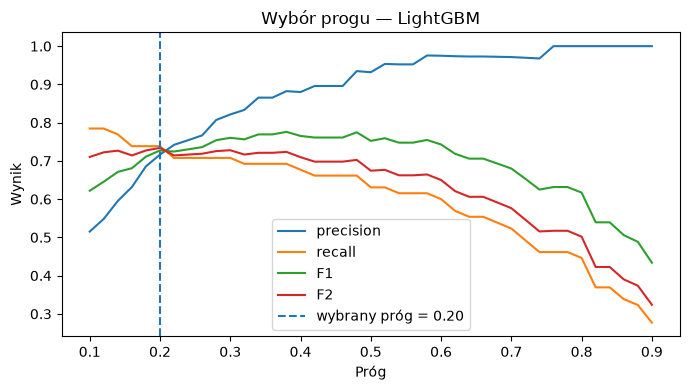

In [7]:
# Wykres pokazuje, jak zmieniają się metryki przy zmianie progu.
plt.figure(figsize=(7, 4))

plt.plot(threshold_df["threshold"], threshold_df["precision"], label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.plot(threshold_df["threshold"], threshold_df["f2"], label="F2")

# Pionowa linia oznacza próg wybrany na walidacji.
plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"wybrany próg = {best_threshold:.2f}"
)

plt.xlabel("Próg")
plt.ylabel("Wynik")
plt.title(f"Wybór progu — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Jedna końcowa ocena na zbiorze testowym

In [8]:
# Od tego miejsca model i próg są już ustalone.
# Test służy tylko do jednej końcowej oceny.
test_proba = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
    "f2": fbeta_score(y_test, test_pred, beta=2, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "ap": average_precision_score(y_test, test_proba),
}

display(pd.DataFrame([test_metrics]).round(4))

,accuracy,precision,recall,f1,f2,roc_auc,ap
0,0.9598,0.6923,0.7683,0.7283,0.7518,0.9636,0.8135


### Wynik na teście

Finalny LightGBM uzyskał:

- accuracy **0,960**,
- precision **0,692**,
- recall **0,768**,
- F1 **0,728**,
- F2 **0,752**,
- ROC-AUC **0,964**,
- AP **0,814**.

Najważniejszy z punktu widzenia celu projektu jest recall: model wykrywa około **77% rzeczywistych bankructw**.

Wyniki testowe są trochę słabsze od walidacyjnych, ale nadal pozostają dobre i potwierdzają, że model generalizuje na nowych danych.

## 9. Confusion matrix

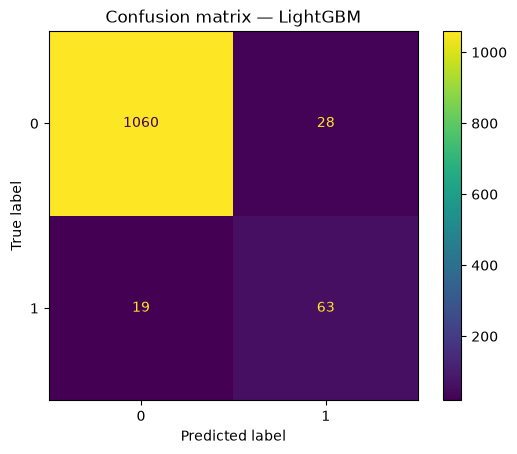

TN: 1060 | FP: 28 | FN: 19 | TP: 63


In [9]:
# Macierz pomyłek pokazuje cztery rodzaje decyzji modelu.
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()
plt.title(f"Confusion matrix — {best_name}")
plt.show()

# Kolejność: TN, FP, FN, TP.
tn, fp, fn, tp = cm.ravel()
print("TN:", tn, "| FP:", fp, "| FN:", fn, "| TP:", tp)

### Interpretacja confusion matrix

Na 1170 firm w teście model:

- poprawnie rozpoznał **1060** firm bez bankructwa (`TN`),
- wygenerował **28** fałszywych alarmów (`FP`),
- nie wykrył **19** bankructw (`FN`),
- poprawnie wykrył **63** bankructwa (`TP`).

W teście było łącznie 82 bankructwa, więc model wykrył **63 z 82**, czyli około **76,8%**.

To oznacza, że obniżony próg spełnił swój cel: model częściej wychwytuje klasę `1`, chociaż pojawia się trochę więcej dodatkowych alarmów.

## 10. Krzywe ROC i Precision-Recall

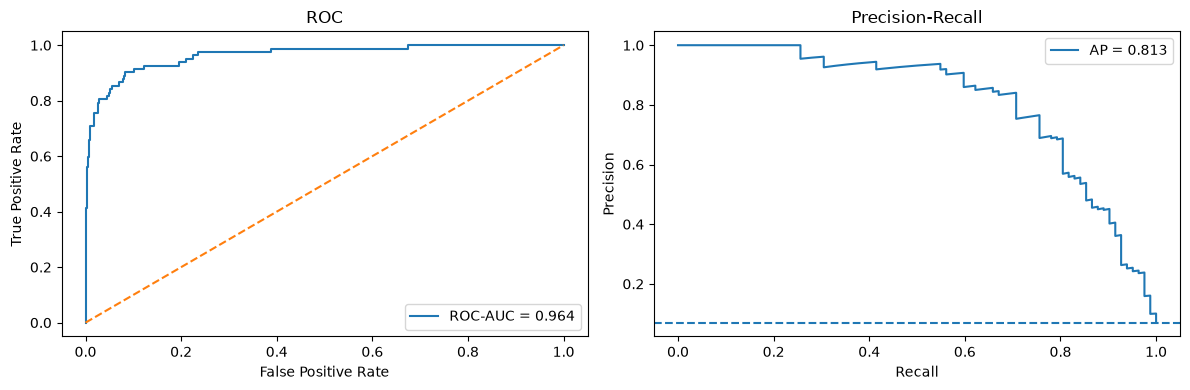

In [10]:
# Krzywe liczę z prawdopodobieństw, a nie z jednej decyzji 0/1.
fpr, tpr, _ = roc_curve(y_test, test_proba)
pr_precision, pr_recall, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC")
axes[0].legend()

axes[1].plot(pr_recall, pr_precision, label=f"AP = {test_metrics['ap']:.3f}")

# Pozioma linia pokazuje udział klasy 1 jako prosty punkt odniesienia.
axes[1].axhline(y_test.mean(), linestyle="--")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Dziesięć najważniejszych cech

,feature,importance
33,Attr34,109
20,Attr21,87
82,missingindicator_Attr21,80
87,missingindicator_Attr27,76
23,Attr24,66
45,Attr46,56
57,Attr58,52
4,Attr5,49
26,Attr27,49
5,Attr6,47


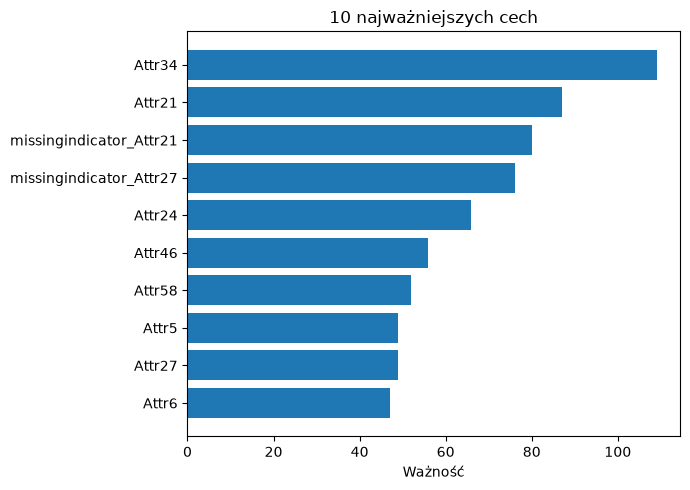

In [11]:
# Wyciągam właściwy klasyfikator z końca Pipeline.
estimator = best_model.named_steps["model"]

if hasattr(estimator, "feature_importances_"):
    # Nazwy po imputacji zawierają też missingindicator_*.
    names = best_model[:-1].get_feature_names_out()
    values = estimator.feature_importances_

    importance = (
        pd.DataFrame({
            "feature": names,
            "importance": values
        })
        .sort_values("importance", ascending=False)
        .head(10)
    )

    display(importance.round(4))

    plt.figure(figsize=(7, 5))
    plt.barh(importance["feature"], importance["importance"])
    plt.gca().invert_yaxis()
    plt.xlabel("Ważność")
    plt.title("10 najważniejszych cech")
    plt.tight_layout()
    plt.show()

else:
    print("Wybrany model nie ma prostego feature_importances_.")

### Wniosek z ważności cech

Najważniejsze są m.in. `Attr34`, `Attr21`, `Attr24`, `Attr46`, `Attr58` i `Attr27`.

W TOP 10 pojawiają się również:

- `missingindicator_Attr21`,
- `missingindicator_Attr27`.

To pasuje do EDA: sam fakt braku danych w niektórych wskaźnikach może pomagać modelowi odróżniać firmy z większym ryzykiem bankructwa.

Ważność cechy nie oznacza jednak, że dana cecha **powoduje** bankructwo. Pokazuje tylko, że model często wykorzystuje ją przy podejmowaniu decyzji.

## 12. Stabilność, przeuczenie i koszt

In [12]:
# Porównuję wynik na treningu i teście, żeby wychwycić mocne przeuczenie.
train_proba = best_model.predict_proba(X_train)[:, 1]
train_pred = (train_proba >= best_threshold).astype(int)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = test_metrics["accuracy"]
accuracy_gap = train_accuracy - test_accuracy

best_tuning_row = tuning_df.loc[tuning_df["model"] == best_name].iloc[0]
cv_row = comparison.loc[comparison["model"] == best_name].iloc[0]

print("Accuracy trening:", round(train_accuracy, 4))
print("Accuracy test:", round(test_accuracy, 4))
print("Różnica train - test:", round(accuracy_gap, 4))
print("AP w pierwszym porównaniu:", round(cv_row["ap_mean"], 4))
print("AP po dokładniejszym strojeniu:", round(best_tuning_row["cv_ap"], 4))
print("Czas dokładniejszego strojenia [s]:", round(best_tuning_row["search_time_s"], 2))

Accuracy trening: 0.992
Accuracy test: 0.9598
Różnica train - test: 0.0322
AP w pierwszym porównaniu: 0.7909
AP po dokładniejszym strojeniu: 0.7875
Czas dokładniejszego strojenia [s]: 18.04


### Wniosek

Accuracy na treningu wynosi około **0,992**, a na teście około **0,960**. Różnica około **0,032** pokazuje pewne dopasowanie do treningu, ale nie jest to załamanie jakości na nowych danych.

Dokładniejsze strojenie nie poprawiło AP LightGBM (`0,7909 → 0,7875`). Oznacza to, że większa liczba obliczeń nie przyniosła tutaj mierzalnej korzyści.

W porównaniu modeli LightGBM był jednocześnie szybszy od Gradient Boosting i uzyskiwał lepszą jakość. To jest prosty argument również z punktu widzenia Green IT: nie wybieram cięższego rozwiązania, jeśli daje słabszy wynik.

## 13. Końcowe podsumowanie

In [13]:
print(f"Model finalny: {best_name}")
print(f"Próg: {best_threshold:.2f}")
print(f"Accuracy: {test_metrics['accuracy']:.3f}")
print(f"Precision: {test_metrics['precision']:.3f}")
print(f"Recall: {test_metrics['recall']:.3f}")
print(f"F1: {test_metrics['f1']:.3f}")
print(f"F2: {test_metrics['f2']:.3f}")
print(f"ROC-AUC: {test_metrics['roc_auc']:.3f}")
print(f"AP: {test_metrics['ap']:.3f}")
print(f"TP: {tp}, FN: {fn}, FP: {fp}, TN: {tn}")

Model finalny: LightGBM
Próg: 0.20
Accuracy: 0.960
Precision: 0.692
Recall: 0.768
F1: 0.728
F2: 0.752
ROC-AUC: 0.964
AP: 0.813
TP: 63, FN: 19, FP: 28, TN: 1060


### Końcowy wniosek

Model finalny to **LightGBM** z progiem **0,20**.

Na teście wykrył **63 z 82 bankructw**. Przeoczył 19, a jednocześnie wygenerował 28 fałszywych alarmów.

Najważniejsze metryki końcowe:

- recall: **0,768**,
- precision: **0,692**,
- F1: **0,728**,
- ROC-AUC: **0,964**,
- AP: **0,814**.

W tym zastosowaniu taki kompromis jest sensowny, ponieważ bardziej zależy mi na wykrywaniu zagrożonych firm niż na całkowitym unikaniu dodatkowych alarmów.

Model nie powinien automatycznie decydować o firmie. Może służyć jako narzędzie do wskazywania przypadków, które warto sprawdzić dokładniej.